Імпорт та завантаження даних


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Очищення завершено. Залишилось пропусків у датасеті: 0


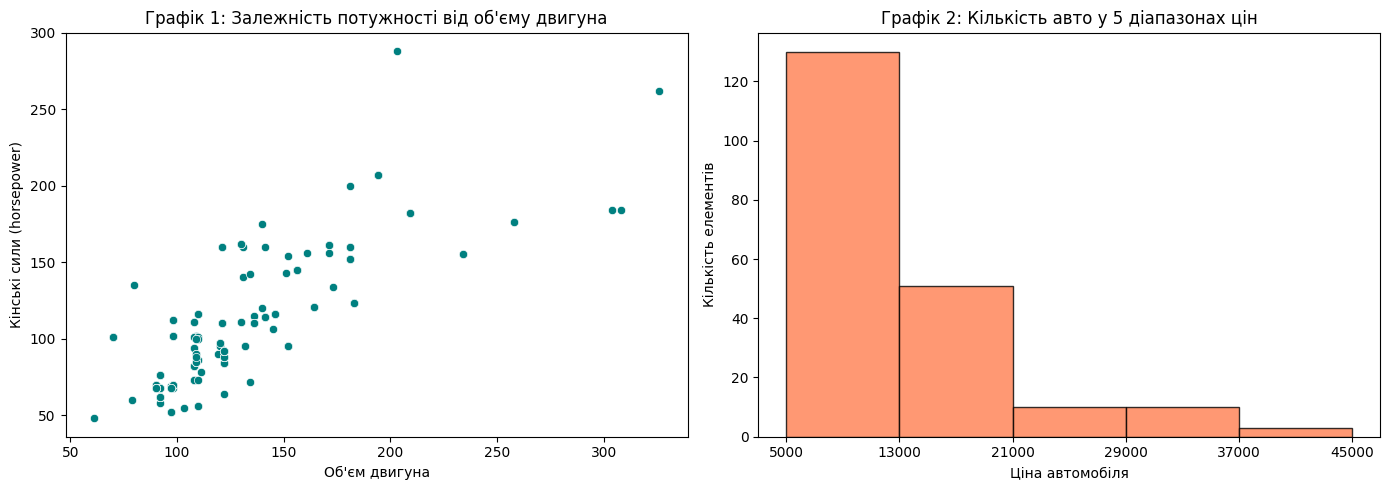

In [ ]:
# 1. Встановлюємо бібліотеку seaborn, якщо її немає в системі
!pip install seaborn

# 2. Імпортуємо всі необхідні інструменти для роботи та візуалізації
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Завантажуємо унікальний датасет Automobile з репозиторію UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location", "wheel-base",
    "length", "width", "height", "curb-weight", "engine-type", "num-of-cylinders",
    "engine-size", "fuel-system", "bore", "stroke", "compression-ratio",
    "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]
df = pd.read_csv(url, names=columns)

# 4. Data Cleaning: очищаємо дані від пропусків '?', як вимагає завдання
df.replace('?', np.nan, inplace=True)

# Перетворюємо числові стовпчики з текстового формату на числовий
num_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Заповнюємо пропущені значення медіаною (числа) або модою (категорії)
df['normalized-losses'] = df['normalized-losses'].fillna(df['normalized-losses'].median())
df['bore'] = df['bore'].fillna(df['bore'].median())
df['stroke'] = df['stroke'].fillna(df['stroke'].median())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df['peak-rpm'] = df['peak-rpm'].fillna(df['peak-rpm'].median())
df['price'] = df['price'].fillna(df['price'].median())
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print(f"Очищення завершено. Залишилось пропусків у датасеті: {df.isnull().sum().sum()}")


# ==========================================
# БЛОК ВІЗУАЛІЗАЦІЇ (БУДУЄМО ПРЕДУСМОТРЕНІ ГРАФІКИ)
# ==========================================

# Графік 1 & 2: Залежність атрибутів та Гістограма на 5 діапазонів
plt.figure(figsize=(14, 5))

# 1. Залежність кінських сил від об'єму двигуна (Scatter plot)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='engine-size', y='horsepower', color='teal')
plt.title('Графік 1: Залежність потужності від об\'єму двигуна')
plt.xlabel('Об\'єм двигуна')
plt.ylabel('Кінські сили (horsepower)')

# 2. Гістограма по одному атрибуту (ціна), розбита строго на 5 діапазонів
plt.subplot(1, 2, 2)
price_bins = [5000, 13000, 21000, 29000, 37000, 45000] # 5 інтервалів
plt.hist(df['price'], bins=price_bins, color='coral', edgecolor='black', alpha=0.8)
plt.title('Графік 2: Кількість авто у 5 діапазонах цін')
plt.xlabel('Ціна автомобіля')
plt.ylabel('Кількість елементів')
plt.xticks(price_bins)

plt.tight_layout()
plt.show()


# Графіки 3, 4, 5: Багатовимірна візуалізація за прикладами зі статті Medium
# 3. Scatter plot з використанням 4-х вимірів (Координати X, Y + Hue колір + Size розмір точок)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='horsepower', 
    y='price', 
    hue='fuel-type',      # 3-й вимір (категорія:газ/бензин)
    size='engine-size',   # 4-й вимір (число: об'єм)
    sizes=(30, 300), 
    alpha=0.7,
    palette='Set1'
)
plt.title('Графік 3 (Medium): Потужність, Ціна, Тип палива та Об\'єм двигуна')
plt.xlabel('Кінські сили')
plt.ylabel('Ціна')
plt.show()

# 4. Violin plot для багатовимірного аналізу категорій та розподілу чисел
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='drive-wheels', y='price', hue='aspiration', split=True, palette='muted')
plt.title('Графік 4 (Medium): Розподіл цін за типом приводу та наддуву')
plt.xlabel('Тип приводу')
plt.ylabel('Ціна')
plt.show()

# 5. Матриця кореляції (Heatmap) для аналізу взаємозв'язків між числовими атрибутами
plt.figure(figsize=(8, 6))
numeric_features = df[['wheel-base', 'length', 'width', 'curb-weight', 'engine-size', 'horsepower', 'price']]
sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Графік 5 (Medium): Матриця кореляції числових ознак')
plt.show()